In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

import torch
from torch.optim.lr_scheduler import SequentialLR, CosineAnnealingLR, LinearLR
from torch.utils.data import DataLoader

from diffusers import UNet2DModel

sys.path.append("../")

from oxels.datasets import PerspectiveImagesDataset
from oxels.networks import SwinUNet
from oxels.losses import original_loss_func
from oxels.augmentation import HueShift, MotionBlur, RandomKernel, RandomBrightnessContrast, PixelNoise, Sobel, Scharr, SequenceStrategy
from oxels.visualization.plot_channels import plot_channels

In [2]:
import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project="oxels",
)

wandb: Currently logged in as: kl_divergence (kl_divergence-rensselaer-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#"harmless" augmentations
basic_augmentations = SequenceStrategy(
    [MotionBlur(), HueShift(), RandomBrightnessContrast()],
    probabilities=[0.8,0.8,0.8],
    ordered=False,
    at_most_one=False)

#more disruptive augmentations that should be applied sparsingly and collide with one another
advanced_agumentation = SequenceStrategy(
    [RandomKernel(), Sobel(), Scharr(), PixelNoise()],
    probabilities=None,
    ordered=False,
    at_most_one=True)

#all augmentations (order matters)
all_agumentations = SequenceStrategy(
    [basic_augmentations, advanced_agumentation],
    probabilities=[1.0, 0.2],
    ordered=True,
    at_most_one=False)

In [5]:
files = glob.glob("../../schenectadata/image-matching-challenge-2022/train/*/images/*.jpg")
# files = glob.glob("../../Pictures/Screenshots/*.png")
dataset = PerspectiveImagesDataset(files, all_agumentations, 256+128, 256, 0.5)

In [6]:
batch_size = 4

In [7]:
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=len(os.sched_getaffinity(0)),
    pin_memory=True,
    shuffle=True,
    drop_last=True
)

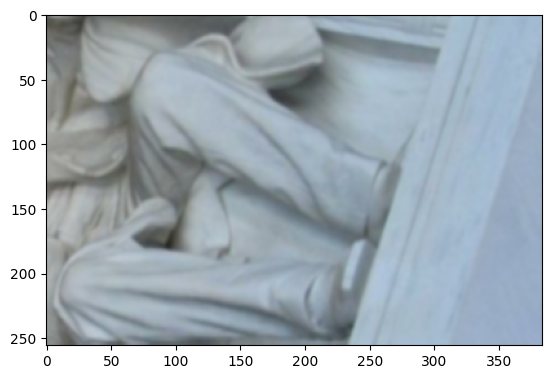

In [8]:
view1, view2, permutation, flags, mask1, mask2 = next(iter(loader))
plt.imshow(view1[0].detach().numpy().transpose((1,2,0)))

In [9]:
dummy_t = torch.tensor([0]).to(device)

In [10]:
network = UNet2DModel(
    sample_size=(256, 384),
    in_channels=3, 
    out_channels=32,
    layers_per_block=2,
    block_out_channels=(32, 64, 128, 256),
    time_embedding_dim=1,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D"
    ),
    up_block_types=(
        "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D"
    ),
).to(device)

In [11]:
%%time
with torch.no_grad():
    oxels1 = network(view1.to(device), dummy_t)["sample"]
    oxels2 = network(view2.to(device), dummy_t)["sample"]
    print(original_loss_func(oxels1, oxels2, permutation.to(device), flags.to(device), mask1.to(device), mask2.to(device)))

tensor(0.3421, device='cuda:0')
CPU times: user 197 ms, sys: 112 ms, total: 309 ms
Wall time: 307 ms


In [ ]:
EPOCHS = 200
SAVE_EVERY = 25
LEARNING_RATE = 9e-5
LOG_EVERY = 5

optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)


warmup_epochs = 1
cosine_epochs = EPOCHS - warmup_epochs

scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(optimizer, start_factor=1e-6, end_factor=1.0, total_iters=warmup_epochs),
        CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=1e-6)
    ],
    milestones=[warmup_epochs]
)

for epoch in range(EPOCHS):
    network.train()
    total_loss = 0.0

    for step, (view1, view2, permutation, flags, mask1, mask2) in enumerate(loader):
        view1 = view1.to(device)
        view2 = view2.to(device)
        permutation = permutation.to(device)
        flags = flags.to(device)
        mask1 = mask1.to(device)
        mask2 = mask2.to(device)

        optimizer.zero_grad()
        oxels1 = network(view1, dummy_t)["sample"]
        oxels2 = network(view2, dummy_t)["sample"]

        loss = original_loss_func(oxels1, oxels2, permutation, flags, mask1, mask2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        if step % LOG_EVERY == 0:
            run.log(data={"loss": loss})

    scheduler.step()

    avg_loss = total_loss / len(loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.3f}, LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save model checkpoint
    if epoch % SAVE_EVERY == 0:
        torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

Epoch 1/200, Loss: 0.348, LR: 9.00e-05


/home/space/anaconda3/envs/oxels/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/200, Loss: 0.132, LR: 9.00e-05
Epoch 3/200, Loss: 0.128, LR: 9.00e-05
Epoch 4/200, Loss: 0.127, LR: 9.00e-05
Epoch 5/200, Loss: 0.127, LR: 8.99e-05
Epoch 6/200, Loss: 0.126, LR: 8.99e-05


In [ ]:
run.finish()

In [ ]:
network.eval()

UNet2DModel(
  (conv_in): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=32, out_features=1, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1, out_features=1, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 32, eps=1e-05, affine=True)
          (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=1, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(32, 32, kernel_size

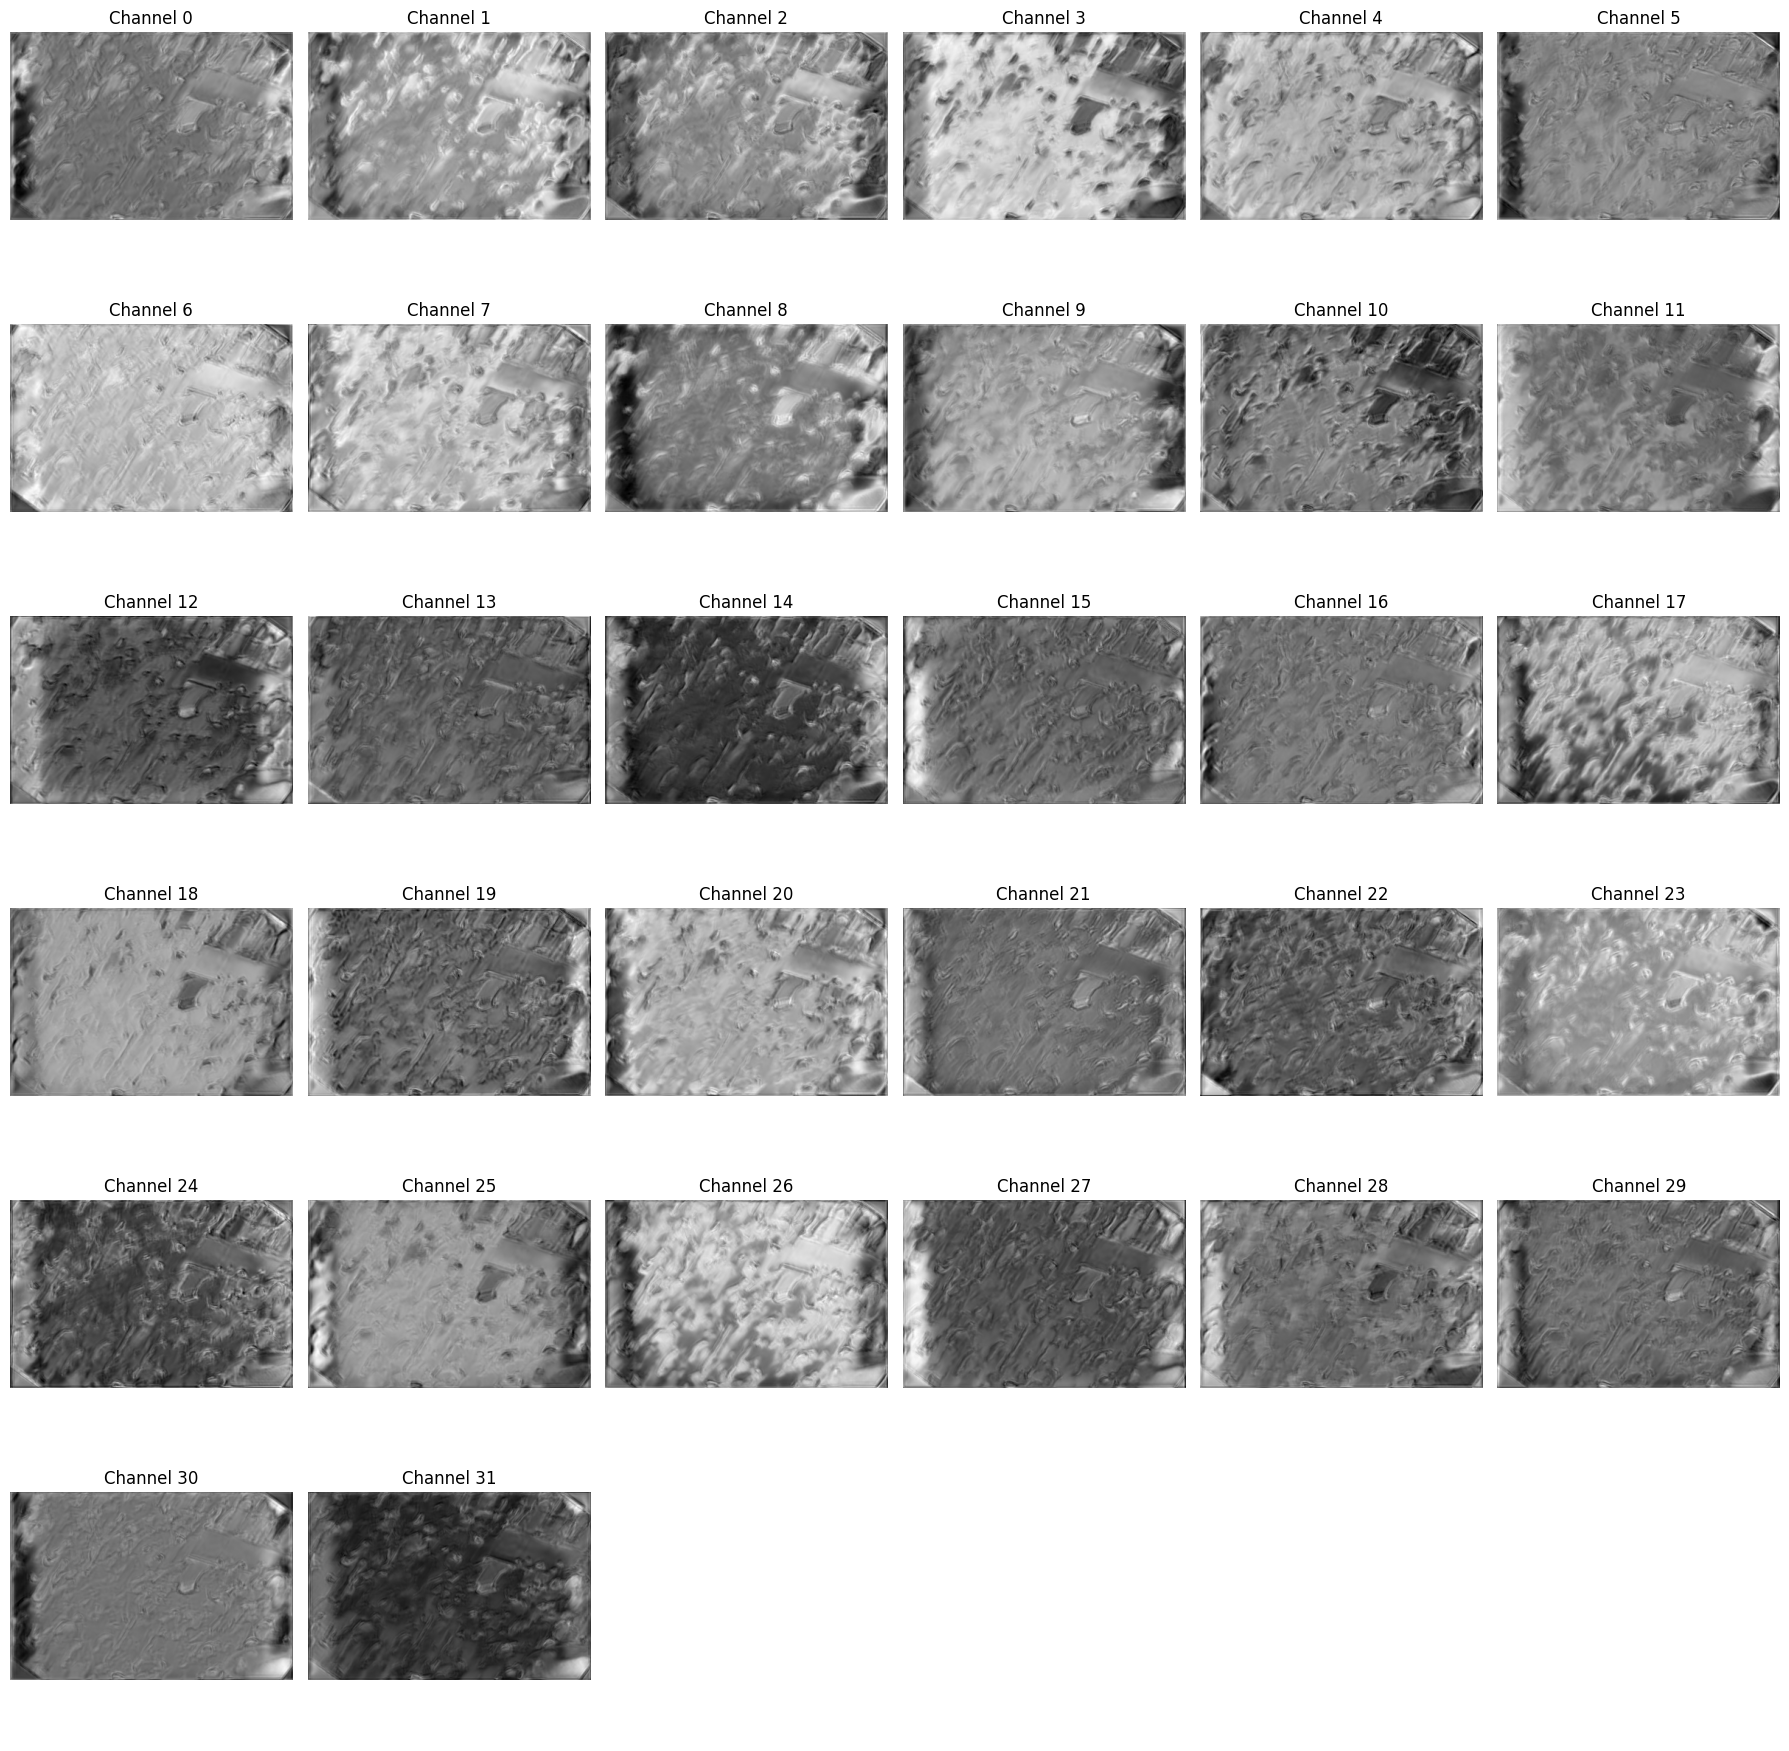

In [ ]:
f = plot_channels(oxels1[1])